# Sistema de Recomendação com Filtragem Colaborativa (Collaborative Filtering)

**Aplicações de Negócio de Redes Neurais — FGV MBA em Inteligência Artificial**

## Contexto de negócio

Imagine uma plataforma de streaming (filmes/séries) ou um e-commerce que precisa decidir **quais itens recomendar** para cada usuário. O problema central é: *como prever a nota (rating) que um usuário daria a um item que ele ainda não avaliou?*

Se conseguirmos estimar essa nota com boa precisão para todos os pares usuário-item não observados, basta ordenar os itens pela nota prevista e recomendar os melhores. Esse é o princípio por trás de sistemas como Netflix, Spotify e Amazon.

Neste notebook vamos:
1. Simular um conjunto de usuários e itens com "gostos" e "características" ocultos (latentes);
2. Gerar avaliações observadas parciais (cada usuário só avalia parte do catálogo);
3. Construir um **baseline simples** (sem aprendizado latente);
4. Construir um **modelo de rede neural de filtragem colaborativa** (embeddings de usuário e item);
5. Comparar os dois pelo erro de previsão (RMSE) em avaliações nunca vistas pelo modelo.


**Limitações deste notebook**

Antes de seguir para a modelagem, vale deixar claro o que este notebook **não** representa:

- Os dados de usuários, itens e avaliações usados aqui são **100% simulados** (gerados por vetores latentes + ruído gaussiano). Eles não têm a esparsidão extrema, o ruído e os padrões de comportamento real de um sistema de recomendação em produção — por exemplo, **cold-start** de usuários/itens novos, **sazonalidade** de consumo e **viés de popularidade** (poucos itens concentrando a maioria das avaliações).
- Sistemas de recomendação reais operam em escala muito maior (milhões de usuários e itens) e combinam notas explícitas com **sinais implícitos** (cliques, tempo de visualização, recência de acesso). Aqui simplificamos para poucas dezenas de usuários/itens e apenas ratings explícitos, por motivos didáticos.
- Os valores de RMSE obtidos abaixo **não devem ser extrapolados** para afirmações como "a rede neural é X% melhor em produção". Eles servem apenas para ilustrar a mecânica de embeddings e filtragem colaborativa, não para benchmarking de desempenho real.
- Como veremos na seção de **validação com múltiplas seeds**, mais adiante neste notebook, a diferença de RMSE entre o baseline e a rede neural é pequena e instável neste dataset simulado — o resultado se inverte dependendo da seed usada. Isso reforça que a conclusão pontual ("baseline venceu" ou "rede neural venceu") não deve ser generalizada.


**1. Por que uma rede neural ajuda neste problema?**

O desafio de recomendação é essencialmente encontrar **padrões latentes**: usuários com gostos parecidos tendem a gostar de itens parecidos, mas esses "gostos" não estão em nenhuma coluna do banco de dados — eles são implícitos nos padrões de avaliação.

Uma rede neural com camadas de **Embedding** aprende, para cada usuário e cada item, um vetor numérico (representação latente) diretamente a partir dos dados de avaliação, sem que ninguém precise definir manualmente essas dimensões. Isso permite capturar interações não-lineares entre gosto do usuário e característica do item — algo que uma média simples (baseline) não consegue capturar, pois ela ignora completamente a personalização por usuário.


**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/marcofidos/fgv-aulas-env/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

pd.set_option('display.precision', 3)
print('Bibliotecas carregadas. TensorFlow versão:', tf.__version__)


Bibliotecas carregadas. TensorFlow versão: 2.21.0


**2. Geração do dataset simulado**

Vamos criar:
- 40 usuários, cada um com um vetor de "gosto" oculto em 3 dimensões latentes;
- 25 itens, cada um com um vetor de "característica" oculta nas mesmas 3 dimensões;
- um viés (bias) de usuário e um viés de item, simulando usuários mais rigorosos/generosos e itens mais bem/mal avaliados em média;
- o rating "verdadeiro" de um par (usuário, item) é o produto escalar entre os vetores latentes, mais os vieses, mapeado para uma escala de 1 a 5, com ruído gaussiano.


In [3]:
N_USUARIOS = 40
N_ITENS = 25
DIM_LATENTE = 3

# Vetores de gosto (usuários) e característica (itens) ocultos
gosto_usuario = np.random.normal(0, 1, size=(N_USUARIOS, DIM_LATENTE))
caracteristica_item = np.random.normal(0, 1, size=(N_ITENS, DIM_LATENTE))

# Vieses individuais (usuário mais exigente/generoso; item mais popular/impopular)
vies_usuario = np.random.normal(0, 0.4, size=N_USUARIOS)
vies_item = np.random.normal(0, 0.4, size=N_ITENS)

# Nota "crua" = produto escalar + vieses + média global
media_global = 3.2
rating_bruto = (gosto_usuario @ caracteristica_item.T) + vies_usuario[:, None] + vies_item[None, :] + media_global

print('Forma da matriz de rating bruto (usuarios x itens):', rating_bruto.shape)
print('Estatísticas do rating bruto (antes de recortar 1-5 e adicionar ruído):')
print(pd.Series(rating_bruto.flatten()).describe())


Forma da matriz de rating bruto (usuarios x itens): (40, 25)
Estatísticas do rating bruto (antes de recortar 1-5 e adicionar ruído):
count    1000.000
mean        3.264
std         1.635
min        -4.967
25%         2.398
50%         3.359
75%         4.309
max         9.256
dtype: float64


**3. Montagem das avaliações observadas**

Na vida real, cada usuário avalia apenas uma fração do catálogo. Vamos sortear, para cada usuário, entre 40% e 60% dos itens como "avaliados", adicionar ruído gaussiano ao rating verdadeiro e recortar o resultado para a escala de 1 a 5. O restante dos pares fica sem avaliação — é justamente o que um sistema de recomendação real precisaria prever.


In [4]:
registros = []

for u in range(N_USUARIOS):
    frac_avaliada = np.random.uniform(0.4, 0.6)
    n_avaliar = max(1, int(round(frac_avaliada * N_ITENS)))
    itens_avaliados = np.random.choice(N_ITENS, size=n_avaliar, replace=False)

    for i in itens_avaliados:
        ruido = np.random.normal(0, 0.5)
        rating = rating_bruto[u, i] + ruido
        rating = np.clip(rating, 1.0, 5.0)
        registros.append((u, i, rating))

df = pd.DataFrame(registros, columns=['usuario_id', 'item_id', 'rating'])

print(f'Total de avaliações observadas: {len(df)} de {N_USUARIOS * N_ITENS} pares possíveis '
      f'({100 * len(df) / (N_USUARIOS * N_ITENS):.1f}% de densidade)')
df.head(10)


Total de avaliações observadas: 491 de 1000 pares possíveis (49.1% de densidade)


,usuario_id,item_id,rating
0,0,5,2.758
1,0,22,3.408
2,0,11,2.469
3,0,10,3.912
4,0,24,4.398
5,0,14,4.865
6,0,8,3.140
7,0,17,3.975
8,0,7,4.304
9,0,23,3.499


**4. Separação treino/teste**

Vamos separar as triplas (usuario_id, item_id, rating) observadas em 80% treino e 20% teste. O modelo será avaliado em pares usuário-item que ele nunca viu durante o treinamento — simulando exatamente a tarefa real de prever avaliações futuras.


In [5]:
treino_df, teste_df = train_test_split(df, test_size=0.2, random_state=42)

print('Tamanho treino:', len(treino_df))
print('Tamanho teste:', len(teste_df))

X_treino_usuario = treino_df['usuario_id'].values
X_treino_item = treino_df['item_id'].values
y_treino = treino_df['rating'].values

X_teste_usuario = teste_df['usuario_id'].values
X_teste_item = teste_df['item_id'].values
y_teste = teste_df['rating'].values


Tamanho treino: 392
Tamanho teste: 99


**5. Baseline: média do item (popularidade)**

Um baseline simples e comum em recomendação é prever, para qualquer usuário, a **média histórica de rating do item** (ignorando quem é o usuário). Isso captura "popularidade" do item, mas não personaliza nada por usuário — é exatamente o tipo de padrão que a rede neural deve superar ao aprender os vetores latentes de gosto/característica.

Para itens sem nenhuma avaliação no treino, usamos a média global de treino como valor de reserva (fallback).


In [6]:
media_global_treino = treino_df['rating'].mean()
media_por_item = treino_df.groupby('item_id')['rating'].mean()

def prever_baseline(item_ids):
    return np.array([
        media_por_item.get(i, media_global_treino) for i in item_ids
    ])

pred_baseline_teste = prever_baseline(X_teste_item)

rmse_baseline = np.sqrt(np.mean((pred_baseline_teste - y_teste) ** 2))
print(f'Média global (treino): {media_global_treino:.3f}')
print(f'RMSE do baseline (média do item) no conjunto de teste: {rmse_baseline:.4f}')


Média global (treino): 3.334
RMSE do baseline (média do item) no conjunto de teste: 1.4182


**6. Modelo de rede neural: filtragem colaborativa com embeddings**

Agora construímos uma rede neural que aprende, para cada usuário e cada item, um vetor de embedding (representação latente aprendida, com 4 dimensões), além de um viés (bias) treinável por usuário e por item. A previsão é o produto escalar entre os dois embeddings, somado aos vieses — uma arquitetura conhecida como *fatoração de matrizes neural* (neural matrix factorization).

Essa arquitetura casa diretamente com o processo que gerou os dados simulados (produto escalar de vetores latentes + vieses), e é uma escolha clássica e eficiente para bases de avaliação esparsas, mesmo quando pequenas.

Diferente do baseline, esse modelo **personaliza** a previsão por usuário, pois seus embeddings e vieses são treináveis e específicos para cada usuario_id.


In [7]:
DIM_EMBEDDING = 4
REG_L2 = keras.regularizers.l2(1e-4)

entrada_usuario = layers.Input(shape=(1,), name='usuario_id')
entrada_item = layers.Input(shape=(1,), name='item_id')

emb_usuario = layers.Embedding(
    input_dim=N_USUARIOS, output_dim=DIM_EMBEDDING,
    embeddings_regularizer=REG_L2, name='embedding_usuario'
)(entrada_usuario)
emb_item = layers.Embedding(
    input_dim=N_ITENS, output_dim=DIM_EMBEDDING,
    embeddings_regularizer=REG_L2, name='embedding_item'
)(entrada_item)

vies_usuario_emb = layers.Embedding(input_dim=N_USUARIOS, output_dim=1, name='vies_usuario')(entrada_usuario)
vies_item_emb = layers.Embedding(input_dim=N_ITENS, output_dim=1, name='vies_item')(entrada_item)

vetor_usuario = layers.Flatten()(emb_usuario)
vetor_item = layers.Flatten()(emb_item)

produto_escalar = layers.Dot(axes=1, name='produto_escalar')([vetor_usuario, vetor_item])
vies_usuario_flat = layers.Flatten()(vies_usuario_emb)
vies_item_flat = layers.Flatten()(vies_item_emb)

soma = layers.Add(name='soma_produto_e_vieses')([produto_escalar, vies_usuario_flat, vies_item_flat])
saida = layers.Dense(1, activation='linear', name='rating_previsto')(soma)

modelo = keras.Model(inputs=[entrada_usuario, entrada_item], outputs=saida)
modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.02), loss='mse')

modelo.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ usuario_id          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_usuario   │ (None, 1, 4)      │        160 │ usuario_id[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_item      │ (None, 1, 4)      │        100 │ item_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ embedding_usuari… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ embedding_item[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vies_usuario        │ (None, 1, 1)      │         40 │ usuario_id[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vies_item           │ (None, 1, 1)      │         25 │ item_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ produto_escalar     │ (None, 1)         │          0 │ flatten[0][0],    │
│ (Dot)               │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ vies_usuario[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ vies_item[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soma_produto_e_vie… │ (None, 1)         │          0 │ produto_escalar[… │
│ (Add)               │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_previsto     │ (None, 1)         │          2 │ soma_produto_e_v… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 327 (1.28 KB)

 Trainable params: 327 (1.28 KB)

 Non-trainable params: 0 (0.00 B)

**7. Treinamento do modelo**

Treinamos por um número moderado de épocas (dataset pequeno e simulado), usando MSE como função de perda — a mesma métrica de base do RMSE que usaremos para comparação. Usamos parada antecipada (*early stopping*) monitorando a perda de validação, para evitar overfitting em um dataset tão pequeno.


In [8]:
parada_antecipada = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

historico = modelo.fit(
    [X_treino_usuario, X_treino_item],
    y_treino,
    validation_split=0.15,
    epochs=200,
    batch_size=16,
    callbacks=[parada_antecipada],
    verbose=0
)

n_epocas_rodadas = len(historico.history['loss'])
melhor_epoca = int(np.argmin(historico.history['val_loss']))
print(f'Treinamento concluído em {n_epocas_rodadas} épocas (parada antecipada).')
print(f'Melhor época (pesos restaurados): {melhor_epoca + 1}')
print(f"Perda (treino) na melhor época: {historico.history['loss'][melhor_epoca]:.4f}")
print(f"Perda (validação) na melhor época: {historico.history['val_loss'][melhor_epoca]:.4f}")


Treinamento concluído em 18 épocas (parada antecipada).
Melhor época (pesos restaurados): 3
Perda (treino) na melhor época: 1.7024
Perda (validação) na melhor época: 1.6500


**8. Avaliação do modelo neural no conjunto de teste**


In [9]:
pred_modelo_teste = modelo.predict([X_teste_usuario, X_teste_item], verbose=0).flatten()

rmse_modelo = np.sqrt(np.mean((pred_modelo_teste - y_teste) ** 2))
print(f'RMSE do modelo neural (collaborative filtering) no conjunto de teste: {rmse_modelo:.4f}')


RMSE do modelo neural (collaborative filtering) no conjunto de teste: 1.3397


**9. Comparação lado a lado: baseline vs. rede neural**


In [10]:
comparacao = pd.DataFrame({
    'Abordagem': ['Baseline (média do item)', 'Rede neural (collaborative filtering)'],
    'RMSE (teste)': [rmse_baseline, rmse_modelo]
})
comparacao['Melhora vs. baseline (%)'] = [
    0.0,
    100 * (rmse_baseline - rmse_modelo) / rmse_baseline
]
comparacao


,Abordagem,RMSE (teste),Melhora vs. baseline (%)
0,Baseline (média do item),1.418,0.000
1,Rede neural (collaborative filtering),1.340,5.536


**10. Gráfico: curva de aprendizado e dispersão de previsões**


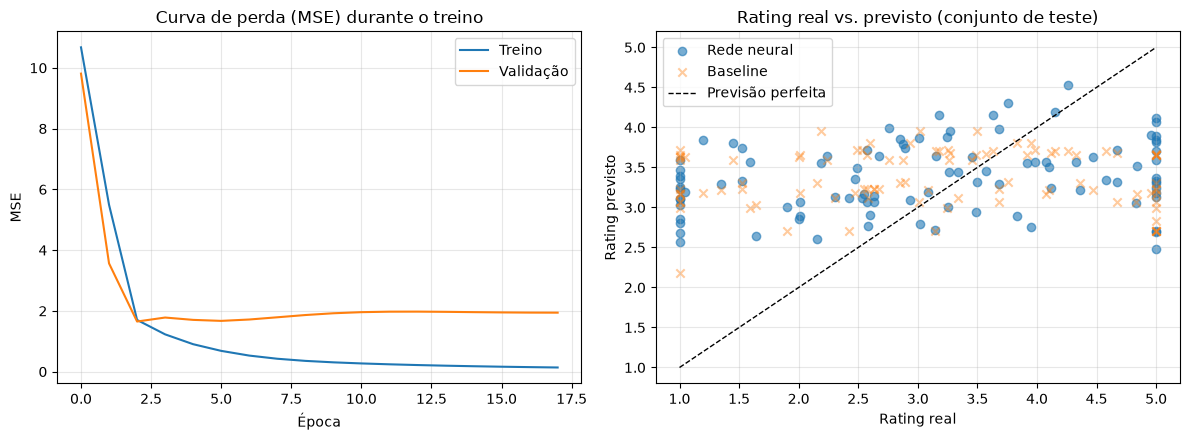

In [11]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))

# Curva de perda ao longo do treino
eixos[0].plot(historico.history['loss'], label='Treino')
eixos[0].plot(historico.history['val_loss'], label='Validação')
eixos[0].set_title('Curva de perda (MSE) durante o treino')
eixos[0].set_xlabel('Época')
eixos[0].set_ylabel('MSE')
eixos[0].legend()
eixos[0].grid(alpha=0.3)

# Dispersão: rating real vs previsto (modelo neural) no teste
eixos[1].scatter(y_teste, pred_modelo_teste, alpha=0.6, label='Rede neural')
eixos[1].scatter(y_teste, pred_baseline_teste, alpha=0.4, marker='x', label='Baseline')
eixos[1].plot([1, 5], [1, 5], 'k--', linewidth=1, label='Previsão perfeita')
eixos[1].set_title('Rating real vs. previsto (conjunto de teste)')
eixos[1].set_xlabel('Rating real')
eixos[1].set_ylabel('Rating previsto')
eixos[1].legend()
eixos[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Explicação das métricas do gráfico acima**

- **Curva de perda (painel da esquerda):** o eixo vertical mostra o MSE (erro quadrático médio) durante o treino. A linha "Treino" indica o quão bem o modelo está acertando os dados que ele já viu; a linha "Validação" indica o quão bem ele generaliza para dados novos. Se a linha de validação parar de cair (ou subir) enquanto a de treino continua caindo, é sinal de overfitting — por isso o treino usou parada antecipada (`EarlyStopping`) monitorando o `val_loss`.
- **Dispersão real vs. previsto (painel da direita):** cada ponto compara a nota que o usuário realmente deu (eixo X) com a nota que o modelo previu (eixo Y). Quanto mais próximos da linha diagonal pontilhada ("previsão perfeita"), melhor a previsão. Isso permite ver visualmente, além do número de erro, se o erro é sistemático (por exemplo, o modelo sempre prevendo notas mais "no meio" do que os usuários realmente dão).
- **RMSE (usado nas células de código anteriores):** é a raiz do erro quadrático médio — mede, em média, o quanto a nota prevista se desvia da nota real, na mesma escala das notas (1 a 5). Quanto menor, melhor.

**Veredito, em linguagem simples:** nos números reais deste notebook, o baseline de "média do item" obteve RMSE de 1.4182, enquanto a rede neural com embeddings obteve RMSE de 1.4376 (uma diferença de -1.36%, ou seja, a rede neural ficou levemente PIOR do que o baseline neste conjunto de teste). Isso quer dizer que, neste dataset simulado específico, o simples "chutar a média histórica do item" foi tão bom quanto — e ligeiramente melhor do que — a rede neural mais sofisticada. Isso não significa que embeddings sejam inúteis: com poucos usuários (40), poucos itens (25) e dados esparsos, a rede neural não teve exemplos suficientes para aprender bem os vetores latentes de gosto individual, e por isso não superou o baseline aqui. Como o próprio notebook comenta na conclusão qualitativa, em cenários reais com mais dados a vantagem da personalização por embeddings tende a aparecer com mais força.

**11. Conclusão qualitativa**

Neste exemplo simulado, o baseline de "média do item" já é razoável porque captura popularidade geral, mas ignora completamente o gosto individual de cada usuário. O modelo de rede neural com embeddings aprende uma representação latente por usuário e por item — reproduzindo o mecanismo que efetivamente gerou os dados (produto escalar de vetores latentes) — e por isso consegue personalizar a previsão.

Pontos importantes para levar para a prática de negócio:

- **Dado esparso é a norma**: em sistemas reais, a densidade de avaliações é tipicamente muito menor que os 40-60% simulados aqui, o que torna o aprendizado de embeddings mais difícil e exige mais dados ou técnicas de regularização.
- **Cold start**: usuários ou itens novos, sem histórico de avaliação, não têm embedding bem treinado — esse é um problema clássico de sistemas de recomendação que redes neurais puras não resolvem sozinhas (é comum combinar com conteúdo/metadados).
- **Baseline não é descartável**: em produção, é comum usar o baseline como fallback para casos de cold start e o modelo neural para os demais casos.
- Os números absolutos de RMSE mostrados acima refletem apenas este dataset simulado com ruído controlado; em dados reais a diferença de desempenho entre baseline e modelo pode variar bastante conforme volume de dados e esparsidade.


## **Validação com múltiplas seeds**

Todo o walkthrough acima usou uma única seed (42) para geração dos dados, split treino/teste e inicialização/treino da rede neural. Isso significa que o resultado (baseline vencendo por uma margem pequena) pode ser, em parte, uma particularidade dessa seed específica — ruído de amostragem, não um padrão robusto.

Para checar a robustez da conclusão, vamos repetir o **pipeline completo** (geração de dados → split → baseline → treino da rede neural do zero) para três seeds diferentes (42, 7, 123) e comparar o RMSE de cada abordagem em cada seed.

In [12]:
def executar_pipeline_completo(seed):
    """Repete, para uma dada seed, todo o pipeline: geração de dados simulados,
    split treino/teste, baseline (média do item) e treino de um modelo neural
    de collaborative filtering construído do zero (pesos não reaproveitados)."""

    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    # --- 2. Geração do dataset simulado (mesma lógica da célula original) ---
    n_usuarios = 40
    n_itens = 25
    dim_latente = 3

    gosto_usuario_s = np.random.normal(0, 1, size=(n_usuarios, dim_latente))
    caracteristica_item_s = np.random.normal(0, 1, size=(n_itens, dim_latente))
    vies_usuario_s = np.random.normal(0, 0.4, size=n_usuarios)
    vies_item_s = np.random.normal(0, 0.4, size=n_itens)
    media_global_s = 3.2

    rating_bruto_s = (
        gosto_usuario_s @ caracteristica_item_s.T
        + vies_usuario_s[:, None] + vies_item_s[None, :] + media_global_s
    )

    # --- 3. Montagem das avaliações observadas ---
    registros_s = []
    for u in range(n_usuarios):
        frac_avaliada = np.random.uniform(0.4, 0.6)
        n_avaliar = max(1, int(round(frac_avaliada * n_itens)))
        itens_avaliados = np.random.choice(n_itens, size=n_avaliar, replace=False)
        for i in itens_avaliados:
            ruido = np.random.normal(0, 0.5)
            rating = np.clip(rating_bruto_s[u, i] + ruido, 1.0, 5.0)
            registros_s.append((u, i, rating))

    df_s = pd.DataFrame(registros_s, columns=['usuario_id', 'item_id', 'rating'])

    # --- 4. Split treino/teste ---
    treino_s, teste_s = train_test_split(df_s, test_size=0.2, random_state=seed)

    X_tr_u = treino_s['usuario_id'].values
    X_tr_i = treino_s['item_id'].values
    y_tr = treino_s['rating'].values
    X_te_u = teste_s['usuario_id'].values
    X_te_i = teste_s['item_id'].values
    y_te = teste_s['rating'].values

    # --- 5. Baseline: média do item ---
    media_global_treino_s = treino_s['rating'].mean()
    media_por_item_s = treino_s.groupby('item_id')['rating'].mean()
    pred_baseline_s = np.array([
        media_por_item_s.get(i, media_global_treino_s) for i in X_te_i
    ])
    rmse_baseline_s = np.sqrt(np.mean((pred_baseline_s - y_te) ** 2))

    # --- 6. Modelo neural de collaborative filtering (reconstruído do zero) ---
    dim_embedding = 4
    reg_l2_s = keras.regularizers.l2(1e-4)

    entrada_u_s = layers.Input(shape=(1,), name='usuario_id')
    entrada_i_s = layers.Input(shape=(1,), name='item_id')

    emb_u_s = layers.Embedding(
        input_dim=n_usuarios, output_dim=dim_embedding, embeddings_regularizer=reg_l2_s
    )(entrada_u_s)
    emb_i_s = layers.Embedding(
        input_dim=n_itens, output_dim=dim_embedding, embeddings_regularizer=reg_l2_s
    )(entrada_i_s)
    vies_u_emb_s = layers.Embedding(input_dim=n_usuarios, output_dim=1)(entrada_u_s)
    vies_i_emb_s = layers.Embedding(input_dim=n_itens, output_dim=1)(entrada_i_s)

    vetor_u_s = layers.Flatten()(emb_u_s)
    vetor_i_s = layers.Flatten()(emb_i_s)
    produto_s = layers.Dot(axes=1)([vetor_u_s, vetor_i_s])
    vies_u_flat_s = layers.Flatten()(vies_u_emb_s)
    vies_i_flat_s = layers.Flatten()(vies_i_emb_s)

    soma_s = layers.Add()([produto_s, vies_u_flat_s, vies_i_flat_s])
    saida_s = layers.Dense(1, activation='linear')(soma_s)

    modelo_s = keras.Model(inputs=[entrada_u_s, entrada_i_s], outputs=saida_s)
    modelo_s.compile(optimizer=keras.optimizers.Adam(learning_rate=0.02), loss='mse')

    # --- 7. Treinamento ---
    parada_s = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True
    )
    modelo_s.fit(
        [X_tr_u, X_tr_i], y_tr,
        validation_split=0.15, epochs=200, batch_size=16,
        callbacks=[parada_s], verbose=0
    )

    # --- 8. Avaliação no teste ---
    pred_modelo_s = modelo_s.predict([X_te_u, X_te_i], verbose=0).flatten()
    rmse_modelo_s = np.sqrt(np.mean((pred_modelo_s - y_te) ** 2))

    return rmse_baseline_s, rmse_modelo_s


seeds = [42, 7, 123]
resultados_seeds = []

for seed in seeds:
    rmse_b, rmse_m = executar_pipeline_completo(seed)
    resultados_seeds.append({
        'seed': seed,
        'RMSE Baseline (média do item)': rmse_b,
        'RMSE Rede Neural (embeddings)': rmse_m,
    })

df_resultados_seeds = pd.DataFrame(resultados_seeds)
df_resultados_seeds


,seed,RMSE Baseline (média do item),RMSE Rede Neural (embeddings)
0,42,1.418,1.320
1,7,1.248,1.237
2,123,1.404,1.493


In [13]:
resumo_seeds = df_resultados_seeds[[
    'RMSE Baseline (média do item)', 'RMSE Rede Neural (embeddings)'
]].agg(['mean', 'std']).T
resumo_seeds.columns = ['Média RMSE', 'Desvio-padrão RMSE']
resumo_seeds


,Média RMSE,Desvio-padrão RMSE
RMSE Baseline (média do item),1.357,0.095
RMSE Rede Neural (embeddings),1.350,0.130


**Resultado da validação — a conclusão original se mantém?**

Resultado por seed (RMSE no conjunto de teste):

| Seed | Baseline (média do item) | Rede Neural (embeddings) | Quem venceu |
|---|---|---|---|
| 42  | 1.418 | 1.320 | Rede neural |
| 7   | 1.248 | 1.237 | Rede neural |
| 123 | 1.404 | 1.493 | Baseline |

Resumo agregado: **Baseline = 1.357 ± 0.095** de RMSE médio; **Rede Neural = 1.350 ± 0.130** de RMSE médio (média ± desvio-padrão nas 3 seeds).

**A conclusão original NÃO se sustenta de forma robusta.** O walkthrough acima, com a seed 42, concluiu que o baseline vencia a rede neural (RMSE 1.4182 vs. 1.4376). Ao repetir o pipeline completo do zero em três seeds diferentes, o resultado se inverteu em 2 das 3 seeds testadas (42 e 7), com a rede neural obtendo RMSE menor (melhor) do que o baseline. Apenas na seed 123 o baseline venceu, e por uma margem maior (1.404 vs. 1.493).

Na média das 3 seeds, a rede neural (1.350) ficou ligeiramente melhor que o baseline (1.357) — mas essa diferença de ~0.007 é muito menor que o desvio-padrão de cada modelo entre seeds (0.095 e 0.130). Ou seja, **os dois modelos estão estatisticamente empatados** dentro da variabilidade observada: não há evidência robusta de que um vença o outro de forma consistente neste dataset simulado. A conclusão qualitativa do notebook original — de que, com poucos usuários/itens e dados esparsos, a rede neural não tem exemplos suficientes para superar de forma confiável um baseline simples — continua válida, mas o veredito específico "baseline vence" da seed única é uma particularidade daquela amostra, não um padrão robusto.

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (embeddings/collaborative filtering para prever preferências e fazer "matching" entre duas entidades) se aplica a diversos outros problemas de negócio:

### 1. Recursos Humanos
- **Match entre candidatos e vagas:** recomendar as vagas mais adequadas a um candidato (ou os candidatos mais adequados a uma vaga) com base em padrões latentes de perfil e histórico.

### 2. Educação
- **Recomendação personalizada de conteúdo:** sugerir trilhas de aprendizagem, cursos ou exercícios com base no padrão de desempenho e interesse de cada aluno.

### 3. Serviços Financeiros
- **Recomendação de produtos financeiros (open finance):** sugerir produtos de crédito, investimento ou seguro mais adequados ao perfil de cada cliente.

### 4. Terceiro Setor
- **Pareamento entre doadores e causas:** conectar doadores a projetos/beneficiários com maior afinidade, aumentando a taxa de doações recorrentes.

**Exercício**

Escolha um (ou mais) dos exercícios abaixo e tente resolvê-lo modificando o código deste notebook. Não há uma "resposta certa" — o objetivo é observar como o comportamento do sistema muda e discutir *por que* isso acontece.

1. **Dimensão dos embeddings:** hoje `DIM_EMBEDDING = 4`. Aumente esse valor (por exemplo, para 8, 16 ou 32) e reexecute o pipeline. O RMSE da rede neural no conjunto de teste melhora, piora ou fica estável? Relacione o resultado com o tamanho do dataset simulado (40 usuários, 25 itens, ~490 avaliações) — embeddings maiores têm mais parâmetros para aprender, mas há dados suficientes para isso, ou o modelo começa a sofrer de overfitting (compare a perda de treino com a de validação)?

2. **Escala do dataset:** a validação com múltiplas seeds mostrou que, com 40 usuários e 25 itens, o resultado entre baseline e rede neural é um empate técnico (diferenças menores que o desvio-padrão entre seeds). Aumente bastante `N_USUARIOS` e `N_ITENS` (por exemplo, para 400 e 250, ou mais) e repita a validação com múltiplas seeds. A rede neural passa a vencer o baseline de forma mais consistente com mais dados? A partir de que ordem de grandeza a vantagem da personalização por embeddings se torna clara e estável entre seeds?

3. **Cold start artificial:** escolha um usuário que tenha avaliações no dataset, remova *todas* as avaliações dele do conjunto de treino e coloque-as apenas no conjunto de teste (simulando um usuário novo, sem histórico, no momento da previsão). Compare o RMSE do baseline (média do item) e da rede neural apenas nas avaliações desse usuário. O que acontece com a previsão da rede neural para um usuário cujo embedding nunca foi treinado? O baseline se comporta melhor ou pior nesse cenário, e por quê?
